In [1]:
# Cell 1 — Imports + global setup
import itertools
import random
import time
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

GLOBAL_SEED = 42

# Experiment design
SEEDS = [0, 1, 2, 3, 4]          # show each seed
BUDGET = 60                      # model trainings per method per seed
GA_POP = 10
GA_GENS = 6                      
assert GA_POP * GA_GENS == BUDGET

# Training knobs 
MAX_ITERS = 80
EARLY_STOP = True

print("Seeds:", SEEDS)
print("Budget per method per seed:", BUDGET)
print("GA:", GA_POP, "pop x", GA_GENS, "gens")

Seeds: [0, 1, 2, 3, 4]
Budget per method per seed: 60
GA: 10 pop x 6 gens


In [2]:
# Cell 2 — Data + split
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=GLOBAL_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=GLOBAL_SEED, stratify=y_trainval
)

# Show data shapes.
print("Train/Val/Test:", X_train.shape, X_val.shape, X_test.shape)

Train/Val/Test: (1077, 64) (360, 64) (360, 64)


In [3]:
# Cell 3 — Search space + helpers

SEARCH_SPACE = {
    "lr": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
    "layers": [1, 2, 3],
    "width": [32, 64, 128, 256],
    "batch": [32, 64, 128],
    "activation": ["relu", "tanh"],
}

# Helper functions to convert between cfg dicts and strings, sample random cfgs, build pipelines, and evaluate val/test acc.
def make_hidden(layers: int, width: int) -> Tuple[int, ...]:
    return tuple([width] * layers)

# Convert cfg dict to a readable string for printing.
def cfg_to_str(cfg: Dict) -> str:
    return f"lr={cfg['lr']}, layers={cfg['layers']}, width={cfg['width']}, batch={cfg['batch']}, act={cfg['activation']}"

# Convert cfg dict to a readable string for printing.
def best_so_far_curve(scores: List[float]) -> List[float]:
    best = -1.0
    out = []
    for s in scores:
        best = max(best, s)
        out.append(best)
    return out

# Sample a random cfg from the search space using the provided random number generator.
def sample_random_cfg(rng: random.Random) -> Dict:
    return {
        "lr": rng.choice(SEARCH_SPACE["lr"]),
        "layers": rng.choice(SEARCH_SPACE["layers"]),
        "width": rng.choice(SEARCH_SPACE["width"]),
        "batch": rng.choice(SEARCH_SPACE["batch"]),
        "activation": rng.choice(SEARCH_SPACE["activation"]),
    }

# Build a sklearn Pipeline with a StandardScaler and an MLPClassifier using the provided cfg and seed.
def build_pipeline(cfg: Dict, seed: int) -> Pipeline:
    hidden = make_hidden(cfg["layers"], cfg["width"])
    # # Initialize the fully connected neural network (FCNN) with the current hyperparameters.
    clf = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=cfg["activation"],
        solver="adam",
        learning_rate_init=cfg["lr"],
        batch_size=cfg["batch"],
        max_iter=MAX_ITERS,
        early_stopping=EARLY_STOP,
        n_iter_no_change=10,
        validation_fraction=0.1,
        random_state=seed,
        tol=1e-4,
        verbose=False,
    )
    return Pipeline([("scaler", StandardScaler()), ("mlp", clf)])

# Train the model with the provided cfg and seed, evaluate on the validation set, and return the validation accuracy.
def train_eval_valacc(cfg: Dict, seed: int) -> float:
    pipe = build_pipeline(cfg, seed)
    pipe.fit(X_train, y_train)
    yhat = pipe.predict(X_val)
    return float(accuracy_score(y_val, yhat))

# Train the model with the provided cfg and seed, evaluate on the test set, and return the test accuracy.
def train_eval_testacc(cfg: Dict, seed: int) -> float:
    # Train on train+val, evaluate on test (simulate final model selection and retraining on all data).
    pipe = build_pipeline(cfg, seed)
    pipe.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))
    yhat = pipe.predict(X_test)
    return float(accuracy_score(y_test, yhat))

# Precompute full grid, but we will only evaluate the first BUDGET points to keep equal budgets.
grid_all = list(itertools.product(
    SEARCH_SPACE["lr"], SEARCH_SPACE["layers"], SEARCH_SPACE["width"], SEARCH_SPACE["batch"], SEARCH_SPACE["activation"]
))
print("Total grid size:", len(grid_all))
print("Using first", BUDGET, "grid points per seed for fairness.")

Total grid size: 360
Using first 60 grid points per seed for fairness.


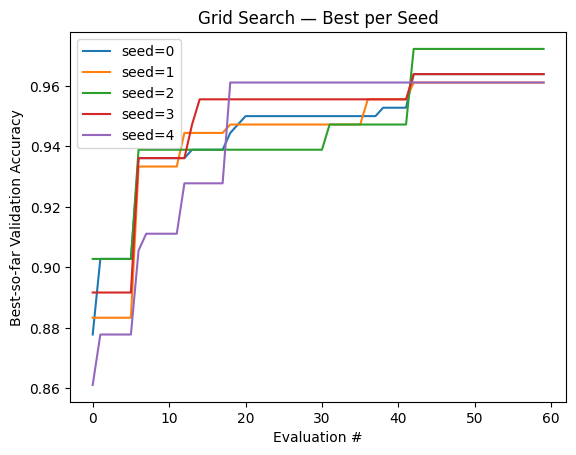

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,2,Grid Search,0.972222,0.950000,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.887500,0.904167,0.579148,36.142525
1,0,Grid Search,0.963889,0.966667,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.888704,0.900000,0.615917,38.879799
2,3,Grid Search,0.963889,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.887315,0.890278,0.601359,38.493748
3,1,Grid Search,0.961111,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",0.887731,0.906944,0.593511,38.296817
4,4,Grid Search,0.961111,0.963889,"lr=0.0001, layers=1, width=256, batch=32, act=...",0.878194,0.906944,0.597089,36.979213


In [4]:
# Cell 4 — Baseline 1: Grid Search (all seeds) + per-seed visuals

grid_results = []     # row-wise results
grid_curves = {}      # seed -> best-so-far curve

# Grid search: evaluate first BUDGET points of the grid for each seed, track best-so-far curve, and final test acc of best val cfg.
for seed in SEEDS:
    scores = []
    cfgs = []
    eval_times = []

    start = time.time()
    # Iterate over the first BUDGET points of the precomputed grid, evaluate val acc, and track eval times.
    for i, (lr, layers, width, batch, activation) in enumerate(grid_all[:BUDGET], start=1):
        cfg = {"lr": lr, "layers": layers, "width": width, "batch": batch, "activation": activation}

        t0 = time.time()
        acc = train_eval_valacc(cfg, seed=seed * 10_000 + i)   # deterministic per seed
        t1 = time.time()

        scores.append(acc)
        cfgs.append(cfg)
        eval_times.append(t1 - t0)

    best_idx = int(np.argmax(scores))
    best_cfg = cfgs[best_idx]
    best_val = scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 99_999)

    grid_curves[seed] = best_so_far_curve(scores)

    grid_results.append({
        "seed": seed,
        "method": "Grid Search",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(scores)),
        "median_val_acc": float(np.median(scores)),
        "avg_eval_time_s": float(np.mean(eval_times)),
        "total_time_s": float(time.time() - start),
    })

# Visual: show EACH seed curve for grid
plt.figure()
for seed in SEEDS:
    plt.plot(grid_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Grid Search — Best per Seed")
plt.legend()
plt.show()

# Show grid results sorted by best_val_acc.
pd.DataFrame(grid_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True)

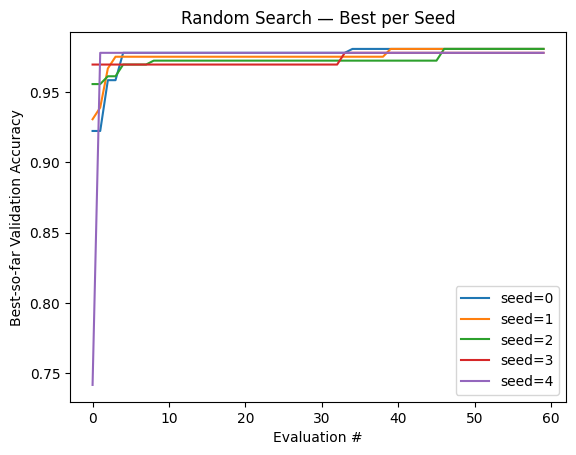

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,0,Random Search,0.980556,0.972222,"lr=0.001, layers=3, width=256, batch=32, act=relu",0.938796,0.958333,0.487621,30.632318
1,1,Random Search,0.980556,0.972222,"lr=0.001, layers=3, width=256, batch=64, act=tanh",0.937731,0.955556,0.481430,30.400994
2,2,Random Search,0.980556,0.975000,"lr=0.003, layers=2, width=256, batch=64, act=relu",0.935926,0.950000,0.441809,27.333153
3,3,Random Search,0.977778,0.966667,"lr=0.01, layers=1, width=256, batch=32, act=tanh",0.934769,0.950000,0.420524,25.614748
4,4,Random Search,0.977778,0.961111,"lr=0.01, layers=1, width=32, batch=32, act=relu",0.932639,0.951389,0.400677,24.216562


In [5]:
# Cell 5 — Baseline 2: Random Search (all seeds) + per-seed visuals

rand_results = []
rand_curves = {}

# Random search: sample BUDGET random points for each seed, track best-so-far curve, and final test acc of best val cfg.
for seed in SEEDS:
    rng = random.Random(GLOBAL_SEED + seed)
    scores = []
    cfgs = []
    eval_times = []

    start = time.time()
    # Iterate over BUDGET random samples, evaluate val acc, and track eval times.
    for i in range(1, BUDGET + 1):
        cfg = sample_random_cfg(rng)

        t0 = time.time()
        acc = train_eval_valacc(cfg, seed=seed * 10_000 + 1_000 + i)
        t1 = time.time()

        scores.append(acc)
        cfgs.append(cfg)
        eval_times.append(t1 - t0)

    best_idx = int(np.argmax(scores))
    best_cfg = cfgs[best_idx]
    best_val = scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 199_999)

    rand_curves[seed] = best_so_far_curve(scores)

    rand_results.append({
        "seed": seed,
        "method": "Random Search",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(scores)),
        "median_val_acc": float(np.median(scores)),
        "avg_eval_time_s": float(np.mean(eval_times)),
        "total_time_s": float(time.time() - start),
    })

# Visual: show EACH seed curve for random
plt.figure()
for seed in SEEDS:
    plt.plot(rand_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Random Search — Best per Seed")
plt.legend()
plt.show()

# Show random results sorted by best_val_acc.
pd.DataFrame(rand_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True)

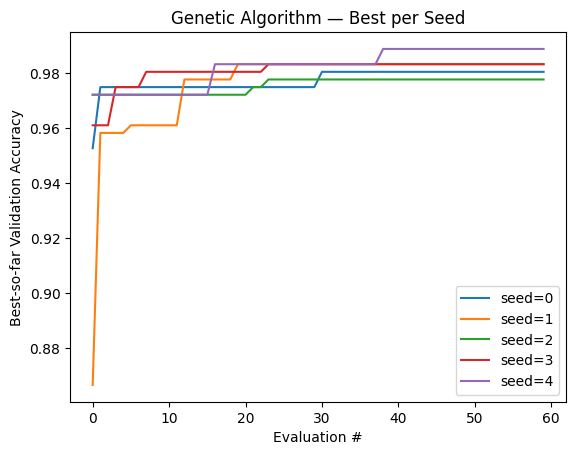

,seed,method,best_val_acc,best_test_acc,best_cfg,avg_val_acc,median_val_acc,avg_eval_time_s,total_time_s
0,4,Genetic Algorithm,0.988889,0.983333,"lr=0.003, layers=2, width=256, batch=32, act=relu",0.947269,0.958333,0.487196,30.663385
1,3,Genetic Algorithm,0.983333,0.969444,"lr=0.01, layers=1, width=256, batch=32, act=relu",0.957454,0.961111,0.410062,25.024334
2,1,Genetic Algorithm,0.983333,0.972222,"lr=0.001, layers=3, width=256, batch=32, act=relu",0.951389,0.958333,0.531083,34.165858
3,0,Genetic Algorithm,0.980556,0.977778,"lr=0.003, layers=3, width=128, batch=64, act=relu",0.957500,0.961111,0.511552,31.182249
4,2,Genetic Algorithm,0.977778,0.963889,"lr=0.01, layers=2, width=64, batch=64, act=tanh",0.950648,0.959722,0.332471,20.122636



=== GA per-generation bests (seed=0) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,0,0,0.975000,"lr=0.003, layers=3, width=128, batch=32, act=relu"
1,0,1,0.975000,"lr=0.003, layers=3, width=128, batch=32, act=relu"
2,0,2,0.975000,"lr=0.003, layers=3, width=128, batch=64, act=relu"
3,0,3,0.980556,"lr=0.003, layers=3, width=128, batch=64, act=relu"
4,0,4,0.977778,"lr=0.003, layers=3, width=128, batch=32, act=relu"
5,0,5,0.969444,"lr=0.003, layers=3, width=128, batch=32, act=relu"



=== GA per-generation bests (seed=1) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,1,0,0.961111,"lr=0.001, layers=3, width=64, batch=64, act=tanh"
1,1,1,0.983333,"lr=0.001, layers=3, width=256, batch=32, act=relu"
2,1,2,0.966667,"lr=0.001, layers=2, width=256, batch=64, act=tanh"
3,1,3,0.972222,"lr=0.001, layers=2, width=256, batch=64, act=tanh"
4,1,4,0.983333,"lr=0.001, layers=2, width=256, batch=32, act=tanh"
5,1,5,0.980556,"lr=0.001, layers=3, width=256, batch=64, act=tanh"


...

,seed,generation,gen_best_val_acc,gen_best_cfg
0,2,0,0.972222,"lr=0.0003, layers=2, width=256, batch=32, act=..."
1,2,1,0.969444,"lr=0.01, layers=2, width=64, batch=64, act=tanh"
2,2,2,0.977778,"lr=0.01, layers=2, width=64, batch=64, act=tanh"
3,2,3,0.975000,"lr=0.01, layers=1, width=128, batch=32, act=tanh"
4,2,4,0.977778,"lr=0.01, layers=1, width=64, batch=32, act=tanh"
5,2,5,0.975000,"lr=0.01, layers=1, width=64, batch=32, act=tanh"



=== GA per-generation bests (seed=3) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,3,0,0.980556,"lr=0.01, layers=2, width=32, batch=64, act=tanh"
1,3,1,0.980556,"lr=0.01, layers=3, width=128, batch=32, act=tanh"
2,3,2,0.983333,"lr=0.01, layers=1, width=256, batch=32, act=relu"
3,3,3,0.983333,"lr=0.01, layers=1, width=256, batch=32, act=relu"
4,3,4,0.975000,"lr=0.01, layers=2, width=256, batch=32, act=relu"
5,3,5,0.975000,"lr=0.01, layers=2, width=256, batch=32, act=relu"



=== GA per-generation bests (seed=4) ===


,seed,generation,gen_best_val_acc,gen_best_cfg
0,4,0,0.972222,"lr=0.001, layers=2, width=256, batch=128, act=..."
1,4,1,0.983333,"lr=0.001, layers=2, width=256, batch=32, act=relu"
2,4,2,0.977778,"lr=0.003, layers=2, width=64, batch=32, act=relu"
3,4,3,0.988889,"lr=0.003, layers=2, width=256, batch=32, act=relu"
4,4,4,0.980556,"lr=0.003, layers=2, width=256, batch=32, act=relu"
5,4,5,0.975000,"lr=0.003, layers=1, width=256, batch=64, act=relu"


In [6]:
# Cell 6 — Method 3: Genetic Algorithm (all seeds) + per-seed visuals + GA-only tables

# Helper functions for tournament selection, uniform crossover, and mutation.
def tournament_select(pop: List[Dict], fits: List[float], rng: random.Random, k: int = 3) -> Dict:
    idxs = rng.sample(range(len(pop)), k)
    best = max(idxs, key=lambda j: fits[j])
    return pop[best]

# Uniform crossover between two parent cfgs to produce a child cfg. Each hyperparameter is randomly chosen from one of the parents with equal probability.
def uniform_crossover(a: Dict, b: Dict, rng: random.Random) -> Dict:
    child = {}
    for key in a.keys():
        child[key] = a[key] if rng.random() < 0.5 else b[key]
    return child

# Mutation of a child cfg with probability pmut per hyperparameter. Each mutated hyperparameter is replaced with a random choice from the search space.
def mutate(cfg: Dict, rng: random.Random, pmut: float = 0.25) -> Dict:
    out = dict(cfg)
    for key, options in SEARCH_SPACE.items():
        if rng.random() < pmut:
            out[key] = rng.choice(options)
    return out

ga_results = []
ga_curves = {}
ga_gen_tables = {} 

# GA search: run GA for each seed, track best-so-far curve, per-generation bests, and final test acc of best val cfg.
for seed in SEEDS:
    ga_rng = random.Random(GLOBAL_SEED + 10_000 + seed)
    pop = [sample_random_cfg(ga_rng) for _ in range(GA_POP)]

    all_scores = []
    all_cfgs = []
    gen_best_rows = []
    eval_times = []  

    start = time.time()
    eval_counter = 0

# Iterate over generations, evaluate each cfg in the population, and track eval times.
    for gen in range(GA_GENS):
        fits = []
        for i in range(GA_POP):
            eval_counter += 1
            cfg = pop[i]

            t0 = time.time()
            acc = train_eval_valacc(cfg, seed=seed * 10_000 + 2_000 + eval_counter)
            t1 = time.time()

            eval_times.append(t1 - t0)
            fits.append(acc)
            all_scores.append(acc)
            all_cfgs.append(cfg)

        best_i = int(np.argmax(fits))
        elite_cfg = pop[best_i]
        elite_fit = fits[best_i]

        gen_best_rows.append({
            "seed": seed,
            "generation": gen,
            "gen_best_val_acc": elite_fit,
            "gen_best_cfg": cfg_to_str(elite_cfg),
        })

        # next generation with elitism=1
        next_pop = [elite_cfg]
        while len(next_pop) < GA_POP:
            p1 = tournament_select(pop, fits, ga_rng, k=3)
            p2 = tournament_select(pop, fits, ga_rng, k=3)
            child = uniform_crossover(p1, p2, ga_rng)
            child = mutate(child, ga_rng, pmut=0.25)
            next_pop.append(child)
        pop = next_pop

    best_idx = int(np.argmax(all_scores))
    best_cfg = all_cfgs[best_idx]
    best_val = all_scores[best_idx]
    best_test = train_eval_testacc(best_cfg, seed=seed * 10_000 + 299_999)

    ga_curves[seed] = best_so_far_curve(all_scores)

    ga_results.append({
        "seed": seed,
        "method": "Genetic Algorithm",
        "best_val_acc": best_val,
        "best_test_acc": best_test,
        "best_cfg": cfg_to_str(best_cfg),
        "avg_val_acc": float(np.mean(all_scores)),
        "median_val_acc": float(np.median(all_scores)),
        "avg_eval_time_s": float(np.mean(eval_times)), 
        "total_time_s": float(time.time() - start),
    })

    ga_gen_tables[seed] = pd.DataFrame(gen_best_rows)

# GA-only independent visuals
plt.figure()
for seed in SEEDS:
    plt.plot(ga_curves[seed], label=f"seed={seed}")
plt.xlabel("Evaluation #")
plt.ylabel("Best-so-far Validation Accuracy")
plt.title("Genetic Algorithm — Best per Seed")
plt.legend()
plt.show()

# Show GA results sorted by best_val_acc.
display(pd.DataFrame(ga_results).sort_values(["best_val_acc"], ascending=False).reset_index(drop=True))

# GA-only generation tables
for seed in SEEDS:
    print(f"\n=== GA per-generation bests (seed={seed}) ===")
    display(ga_gen_tables[seed])

In [7]:
# Cell 7 — average (and best) best-so-far curves across seeds

# Helper function to pad curves to the same length by holding the last value, so we can compute mean and std dev across seeds.
def pad_to_len(curves: List[List[float]], L: int) -> np.ndarray:
    arr = []
    for c in curves:
        if len(c) < L:
            c = c + [c[-1]] * (L - len(c))
        arr.append(c[:L])
    return np.array(arr, dtype=float)

# Compute mean and std dev of best-so-far curves across seeds for each method. Returns two arrays of shape (L,) where L is the max curve length.
def mean_std_curve(curve_dict: Dict[int, List[float]]) -> Tuple[np.ndarray, np.ndarray]:
    # curve_dict: seed -> curve list
    curves = list(curve_dict.values())
    L = max(len(c) for c in curves)
    mat = pad_to_len(curves, L)
    return mat.mean(axis=0), mat.std(axis=0)

# Get the seed with the best final val acc for a given method, so we can highlight its curve in the final visual.
def best_seed_by_metric(rows: pd.DataFrame, method: str, metric: str = "best_val_acc") -> int:
    sub = rows[rows["method"] == method].copy()
    return int(sub.sort_values(metric, ascending=False).iloc[0]["seed"])

# Build a single dataframe with all results for easy comparison and final table display.
all_rows = pd.DataFrame(grid_results + rand_results + ga_results)

# Final visual: plot mean best-so-far curve with error bars for each method, and highlight the best seed curve for each method.
best_cfg_table = all_rows[["method","seed","best_val_acc","best_test_acc","best_cfg","total_time_s"]].copy()
best_cfg_table = best_cfg_table.sort_values(["method","seed"]).reset_index(drop=True)
best_cfg_table

,method,seed,best_val_acc,best_test_acc,best_cfg,total_time_s
0,Genetic Algorithm,0,0.980556,0.977778,"lr=0.003, layers=3, width=128, batch=64, act=relu",31.182249
1,Genetic Algorithm,1,0.983333,0.972222,"lr=0.001, layers=3, width=256, batch=32, act=relu",34.165858
2,Genetic Algorithm,2,0.977778,0.963889,"lr=0.01, layers=2, width=64, batch=64, act=tanh",20.122636
3,Genetic Algorithm,3,0.983333,0.969444,"lr=0.01, layers=1, width=256, batch=32, act=relu",25.024334
4,Genetic Algorithm,4,0.988889,0.983333,"lr=0.003, layers=2, width=256, batch=32, act=relu",30.663385
5,Grid Search,0,0.963889,0.966667,"lr=0.0001, layers=2, width=256, batch=32, act=...",38.879799
6,Grid Search,1,0.961111,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",38.296817
7,Grid Search,2,0.972222,0.950000,"lr=0.0001, layers=2, width=256, batch=32, act=...",36.142525
8,Grid Search,3,0.963889,0.983333,"lr=0.0001, layers=2, width=256, batch=32, act=...",38.493748
9,Grid Search,4,0.961111,0.963889,"lr=0.0001, layers=1, width=256, batch=32, act=...",36.979213
